# Hotel Cancellation - EDA to Final Model

Workflow:
1. Load and inspect data
2. Clean data and prepare target
3. Do EDA and check signal
4. Shortlist features from analysis
5. Train baseline and final models
6. Save final artifacts for deployment


In [74]:
import os
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
RANDOM_STATE = 42
TOP_K = 6


In [75]:
# load data
raw_df = pd.read_csv("hotel.csv")
df = raw_df.copy()

print("shape:", df.shape)
print("columns:", len(df.columns))


shape: (36275, 19)
columns: 19


In [76]:
# quick inspection
print("column names:")
print(df.columns.tolist())
print()
print("first rows:")
print(df.head().to_string(index=False))


column names:
['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'booking_status']

first rows:
Booking_ID  no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights type_of_meal_plan  required_car_parking_space room_type_reserved  lead_time  arrival_year  arrival_month  arrival_date market_segment_type  repeated_guest  no_of_previous_cancellations  no_of_previous_bookings_not_canceled  avg_price_per_room  no_of_special_requests booking_status
  INN00001             2               0                     1                  2       Meal Plan 1                           0        Room_Type 1        224          2017             10             2 

In [77]:
# missing value check
print("missing values:")
print(df.isna().sum())


missing values:
Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64


In [78]:
# clean text and duplicates
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip()

before = len(df)
df = df.drop_duplicates(subset=["Booking_ID"]).copy()
print("duplicate rows removed:", before - len(df))


duplicate rows removed: 0


In [79]:
# target and basic derived fields
df["cancellation"] = df["booking_status"].map({"Not_Canceled": 0, "Canceled": 1})
df["total_nights"] = df["no_of_weekend_nights"] + df["no_of_week_nights"]
df["total_guests"] = df["no_of_adults"] + df["no_of_children"]


In [80]:
# compact segment mapping + encoding
def map_segment(x):
    x = str(x).strip().lower()
    return "Online" if x == "online" else "Offline"

df["market_segment_type_mapped"] = df["market_segment_type"].apply(map_segment)
segment_encoder = LabelEncoder()
df["market_segment_type_encoded"] = segment_encoder.fit_transform(df["market_segment_type_mapped"])

print("segment classes:", list(segment_encoder.classes_))


segment classes: ['Offline', 'Online']


In [81]:
# class distribution
print("class balance:")
print(df["booking_status"].value_counts())


class balance:
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64


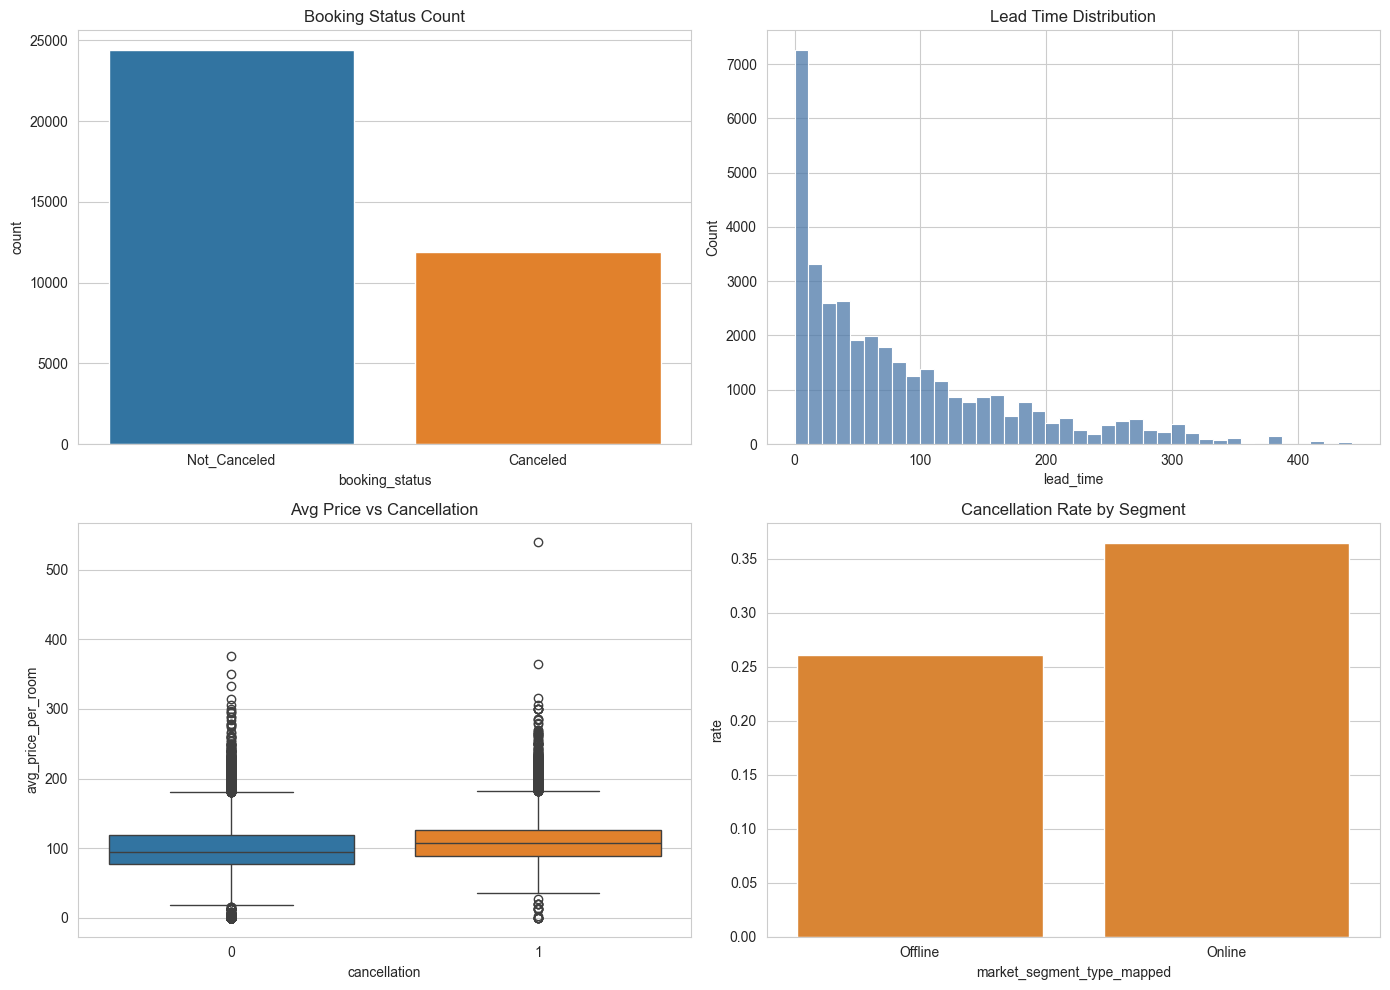

In [82]:
# EDA: status count, lead-time hist, price boxplot, segment cancellation rate
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="booking_status", hue="booking_status", legend=False, ax=ax[0, 0])
ax[0, 0].set_title("Booking Status Count")

sns.histplot(data=df, x="lead_time", bins=40, color="#4C78A8", ax=ax[0, 1])
ax[0, 1].set_title("Lead Time Distribution")

sns.boxplot(data=df, x="cancellation", y="avg_price_per_room", hue="cancellation", legend=False, ax=ax[1, 0])
ax[1, 0].set_title("Avg Price vs Cancellation")

segment_rate = df.groupby("market_segment_type_mapped", as_index=False)["cancellation"].mean()
sns.barplot(data=segment_rate, x="market_segment_type_mapped", y="cancellation", color="#F58518", ax=ax[1, 1])
ax[1, 1].set_title("Cancellation Rate by Segment")
ax[1, 1].set_ylabel("rate")

plt.tight_layout()
plt.show()


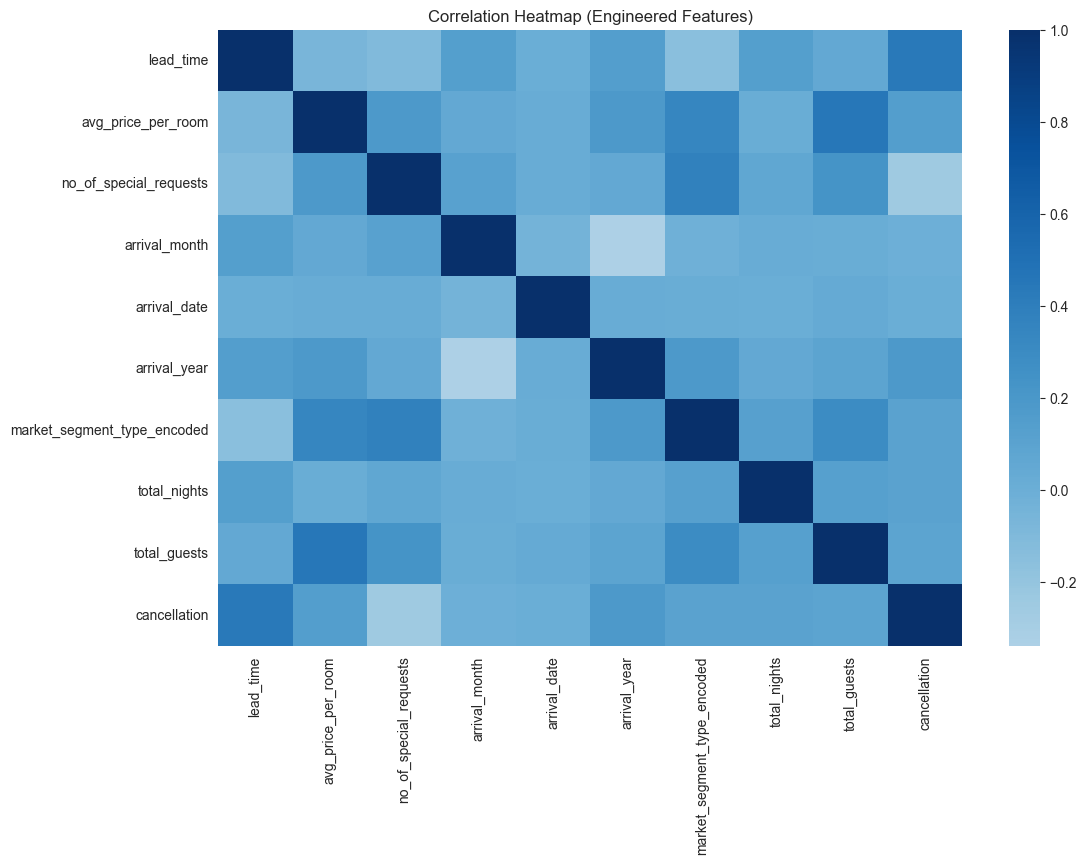

In [83]:
# correlation heatmap (curated engineered set)
heatmap_cols = [
    "lead_time",
    "avg_price_per_room",
    "no_of_special_requests",
    "arrival_month",
    "arrival_date",
    "arrival_year",
    "market_segment_type_encoded",
    "total_nights",
    "total_guests",
    "cancellation",
]

corr_matrix = df[heatmap_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="Blues", center=0)
plt.title("Correlation Heatmap (Engineered Features)")
plt.show()


In [84]:
# rank correlation with target
corr_with_target = corr_matrix["cancellation"].drop("cancellation")
corr_rank = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)

print("top correlations with cancellation (absolute):")
print(corr_rank.head(12).to_string())


top correlations with cancellation (absolute):
lead_time                      0.438538
no_of_special_requests        -0.253070
arrival_year                   0.179529
avg_price_per_room             0.142569
market_segment_type_encoded    0.106362
total_nights                   0.103475
total_guests                   0.089810
arrival_month                 -0.011233
arrival_date                   0.010629


In [ ]:
print(df['no_of_special_requests'].unique())

NameError: name 'df' is not defined

In [85]:
# shortlist from EDA ranking (restricted to deployment-safe features)
deployable_feature_pool = [
    "lead_time",
    "avg_price_per_room",
    "no_of_special_requests",
    "arrival_month",
    "market_segment_type_encoded",
    "arrival_date",
    "total_nights",
    "arrival_year",
    "no_of_week_nights",
    "no_of_weekend_nights",
]

deployable_feature_pool = [c for c in deployable_feature_pool if c in df.columns]
ranked_features = corr_rank.index.tolist()

selected_features = [c for c in ranked_features if c in deployable_feature_pool][:TOP_K]
if len(selected_features) < 4:
    selected_features = deployable_feature_pool[:TOP_K]

print("deployable pool:", deployable_feature_pool)
print("selected from EDA ranking:", selected_features)


deployable pool: ['lead_time', 'avg_price_per_room', 'no_of_special_requests', 'arrival_month', 'market_segment_type_encoded', 'arrival_date', 'total_nights', 'arrival_year', 'no_of_week_nights', 'no_of_weekend_nights']
selected from EDA ranking: ['lead_time', 'no_of_special_requests', 'arrival_year', 'avg_price_per_room', 'market_segment_type_encoded', 'total_nights']


In [86]:
# prepare model datasets
X_base = df[deployable_feature_pool].copy()
X_final = df[selected_features].copy()
y = df["cancellation"].copy()

for c in deployable_feature_pool:
    X_base[c] = pd.to_numeric(X_base[c], errors="coerce")
X_base = X_base.fillna(X_base.median(numeric_only=True))

for c in selected_features:
    X_final[c] = pd.to_numeric(X_final[c], errors="coerce")
X_final = X_final.fillna(X_final.median(numeric_only=True))


In [87]:
# split data
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train_final = X_train_base[selected_features]
X_test_final = X_test_base[selected_features]


In [88]:
# baseline model (full deployable pool)
baseline_model = RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1)
baseline_model.fit(X_train_base, y_train)

base_pred = baseline_model.predict(X_test_base)
base_proba = baseline_model.predict_proba(X_test_base)[:, 1]

print("baseline accuracy:", round(accuracy_score(y_test, base_pred), 4))
print("baseline auc:", round(roc_auc_score(y_test, base_proba), 4))


baseline accuracy: 0.9052
baseline auc: 0.9566


In [89]:
# final model (shortlisted features)
final_model = RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1)
final_model.fit(X_train_final, y_train)

final_pred = final_model.predict(X_test_final)
final_proba = final_model.predict_proba(X_test_final)[:, 1]

print("final accuracy:", round(accuracy_score(y_test, final_pred), 4))
print("final auc:", round(roc_auc_score(y_test, final_proba), 4))
print()
print("final model report:")
print(classification_report(y_test, final_pred, target_names=["Not Canceled", "Canceled"]))


final accuracy: 0.8889
final auc: 0.9397

final model report:
              precision    recall  f1-score   support

Not Canceled       0.91      0.93      0.92      4878
    Canceled       0.85      0.80      0.83      2377

    accuracy                           0.89      7255
   macro avg       0.88      0.87      0.87      7255
weighted avg       0.89      0.89      0.89      7255



In [90]:
# save final artifacts
MODEL_DIR = "model_files"
os.makedirs(MODEL_DIR, exist_ok=True)

RF_MODEL_PATH = os.path.join(MODEL_DIR, "random_forest_model.pkl")
ENCODERS_PATH = os.path.join(MODEL_DIR, "encoders.pkl")
FEATURE_COLS_PATH = os.path.join(MODEL_DIR, "feature_cols.pkl")
IMPORTANCE_PATH = os.path.join(MODEL_DIR, "feature_importance_full.csv")
SELECTED_FEATURES_PATH = os.path.join(MODEL_DIR, "selected_features.csv")

final_importance = pd.DataFrame({
    "feature": selected_features,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=False)

with open(RF_MODEL_PATH, "wb") as f:
    pickle.dump(final_model, f)

encoders = {"market_segment_type": segment_encoder}
with open(ENCODERS_PATH, "wb") as f:
    pickle.dump(encoders, f)

with open(FEATURE_COLS_PATH, "wb") as f:
    pickle.dump(selected_features, f)

final_importance.to_csv(IMPORTANCE_PATH, index=False)
pd.DataFrame({"selected_feature": selected_features}).to_csv(SELECTED_FEATURES_PATH, index=False)

assert set(selected_features).issubset(set(deployable_feature_pool))
assert "market_segment_type" in encoders

with open(FEATURE_COLS_PATH, "rb") as f:
    loaded_feature_cols = pickle.load(f)
assert loaded_feature_cols == selected_features
_ = final_model.predict_proba(pd.DataFrame([{k: 0 for k in loaded_feature_cols}]))

print("saved files:")
print(RF_MODEL_PATH)
print(ENCODERS_PATH)
print(FEATURE_COLS_PATH)
print(IMPORTANCE_PATH)
print(SELECTED_FEATURES_PATH)


saved files:
model_files\random_forest_model.pkl
model_files\encoders.pkl
model_files\feature_cols.pkl
model_files\feature_importance_full.csv
model_files\selected_features.csv


### Notes

- Feature selection was done after cleanup + EDA.
- Final feature list is restricted to deployment-safe inputs so the app can use the same artifacts directly.
